In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# # for google colab

# !pip install pypose
# !pip install kornia

In [3]:
# from google.colab import drive
# drive.mount('/content/drive')
# !unzip -q /content/drive/MyDrive/SonarOdometryDataset/SonarOdometryDataset_sample.zip -d /content/drive/MyDrive/SonarOdometryDataset/SonarOdometryDataset_sample

In [4]:
# %cd /content/
# !git clone https://github.com/MarcinJanis/SonarOdometry.git
# %cd SonarOdometry


In [ ]:
import os
import sys

import cv2

import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

from box import Box
import yaml

import matplotlib.pyplot as plt

from scipy.spatial.transform import Rotation as R
import random

import time

from tqdm import tqdm

import pywt
from sklearn.decomposition import MiniBatchDictionaryLearning
from sklearn.feature_extraction.image import extract_patches_2d, reconstruct_from_patches_2d
import warnings


root_dir = os.path.abspath('../..')
if root_dir not in sys.path:
    sys.path.append(root_dir)

from src.data_loader.evaluation_data_generator import DataGenerator
from src.models.patchifier import Patchifier

from src.data_loader.metrics import eval_metrics_2d
# from training.utils import pose_err




In [20]:
root_dir = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry'
# root_dir = '/content/SonarOdometry'

model_config_pth = os.path.join(root_dir, 'config/model2d.yaml')
sonar_config_pth = os.path.join(root_dir, 'config/sonar.yaml')

data_root_dir = os.path.join(root_dir, 'data/aracati2017')

# data_root_dir = '/content/drive/MyDrive/SonarOdometryDataset/SonarOdometryDataset_sample/SonarOdometryDataset_sample/seq_15'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open(model_config_pth, "r") as f:
            model_config = Box(yaml.safe_load(f))

with open(sonar_config_pth, "r") as f:
            sonar_config = Box(yaml.safe_load(f))

from src.models.utils import ExtrinsicsCalib
extrinsics_calib = ExtrinsicsCalib(T = [sonar_config.position.x, sonar_config.position.y, sonar_config.position.z],
                                   R = [sonar_config.position.roll, sonar_config.position.pitch, sonar_config.position.yaw])


from src.data_loader.transforms import SonarDatasetTranforms


fls_resolution = (model_config.POLAR_FLS_INPUT_HEIGHT, model_config.POLAR_FLS_INPUT_WIDTH) # for own ds
fls_resolution = (model_config.CART_FLS_INPUT_HEIGHT, model_config.CART_FLS_INPUT_WIDTH) # for aracati 

data_generator = DataGenerator(data_root_dir, device, fls_resolution=fls_resolution, transforms = None, calibration = extrinsics_calib)
data_lenght = data_generator.get_len()
print(f'Data generator initialized.')
print(f'Data series lenght: {data_lenght}')


from src.models.odometry2d import sonar_odometry



Data generator initialized.
Data series lenght: 14436


In [21]:
# def display_format(frame):

#     _, c, h, w = frame.shape

#     # corect dimensions
#     frame_reshaped = frame.view(h, w, 1)

#     # convert to numpy 
#     frame_np = frame_reshaped.detach().cpu().numpy()

#     # corect values and dtype
#     frame_disp = (frame_np * 255).astype(np.uint8)

#     return frame_disp


# def normalize_sonar_frame(frame_tensor):
#     # Zamiast CLAHE/Blur, zastosuj statystyczną normalizację:
#     # 1. Obetnij wartości odstające (np. 2% najjaśniejszych i najciemniejszych)
#     # 2. Przeskaluj do [0, 1]
    
#     # Opcja 1: Standardowa (Zero Mean, Unit Variance)
#     mean = frame_tensor.mean()
#     std = frame_tensor.std()
#     return (frame_tensor - mean) / (std + 1e-6)


# --- FUNKCJA POMOCNICZA DO OCENY DOPASOWAŃ ---
def evaluate_loftr_pair(img1_tensor, img2_tensor, mask, matcher, match_thresh=0.4, ransac_thresh=4.0):
    """ Przeprowadza dopasowanie LoFTR i weryfikację RANSAC. """
    input_dict = {
        'image0': img1_tensor,
        'mask0': mask,
        'image1': img2_tensor,
        'mask1': mask
    }
    
    with torch.no_grad():
        matches = matcher(input_dict)
        
    pts1 = matches['keypoints0']
    pts2 = matches['keypoints1']
    confidence = matches['confidence']
    
    # Filtrowanie po pewności dopasowania (confidence)
    valid = confidence > match_thresh
    pts1_np = pts1[valid].cpu().numpy()
    pts2_np = pts2[valid].cpu().numpy()
    conf_np = confidence[valid].cpu().numpy()
    
    inliers_mask = None
    inliers_abs = 0
    inliers_ratio = 0.0
    
    # RANSAC do weryfikacji fizycznej poprawności
    if len(pts1_np) >= 3:
        # Metoda Partial2D jest odporna na szum i pozwala na obrót/przesunięcie/skalę
        M, inliers_mask = cv2.estimateAffinePartial2D(
            pts2_np, pts1_np, method=cv2.RANSAC, 
            ransacReprojThreshold=ransac_thresh, maxIters=3000, confidence=0.999
        )
        if inliers_mask is not None:
            inliers_mask = inliers_mask.ravel().astype(bool)
            inliers_abs = int(inliers_mask.sum())
            inliers_ratio = inliers_abs / len(pts1_np)
            
    return {
        'total_matches': len(pts1_np),
        'inliers_abs': inliers_abs,
        'inliers_ratio': inliers_ratio,
        'mean_conf': float(np.mean(conf_np)) if len(conf_np) > 0 else 0.0,
        'pts1': pts1_np,
        'pts2': pts2_np,
        'inliers_mask': inliers_mask
    }

# --- FUNKCJA WIZUALIZACYJNA ---
def plot_loftr_evaluation(img1_tensor, img2_tensor, metrics, title):
    """ Rysuje dopasowania: ZIELONE to inliers (poprawne), CZERWONE to outliers (błędne). """
    # Konwersja do numpy [0, 255] dla OpenCV
    img1_cv = (img1_tensor.squeeze().cpu().numpy() * 255).astype(np.uint8)
    img2_cv = (img2_tensor.squeeze().cpu().numpy() * 255).astype(np.uint8)
    
    img1_rgb = cv2.cvtColor(img1_cv, cv2.COLOR_GRAY2RGB)
    img2_rgb = cv2.cvtColor(img2_cv, cv2.COLOR_GRAY2RGB)
    
    pts1 = metrics['pts1']
    pts2 = metrics['pts2']
    inliers_mask = metrics['inliers_mask']
    
    kpts1 = [cv2.KeyPoint(x=float(p[0]), y=float(p[1]), size=5) for p in pts1]
    kpts2 = [cv2.KeyPoint(x=float(p[0]), y=float(p[1]), size=5) for p in pts2]
    
    matches_obj = [cv2.DMatch(_queryIdx=i, _trainIdx=i, _distance=0) for i in range(len(pts1))]
    
    # Rysowanie tylko poprawnych dopasowań
    out_img = cv2.drawMatches(
        img1_rgb, kpts1, img2_rgb, kpts2, matches_obj, None, 
        matchColor=(0, 255, 0), # Zielone dla inlierów
        singlePointColor=(255, 0, 0), # Niebieskie dla odrzuconych (outlierów)
        matchesMask=inliers_mask.tolist() if inliers_mask is not None else None,
        flags=cv2.DrawMatchesFlags_DEFAULT
    )
    
    plt.figure(figsize=(16, 7))
    plt.title(f"{title}\nTotal Matches (Conf > threshold): {metrics['total_matches']} | "
              f"Valid Inliers: {metrics['inliers_abs']} ({metrics['inliers_ratio']:.1%}) | "
              f"Avg Conf: {metrics['mean_conf']:.3f}", fontsize=14)
    plt.imshow(out_img)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


In [22]:
def fls_filter(frame):
        """ Filtracja obrazu: MedianBlur + Bilateral + CLAHE (Zapożyczone z zeszytu) """
        device = frame.device 
        b, c, h, w = frame.shape
        out_frames = []
        for i in range(b):
            frame_np = frame[i, 0].detach().cpu().numpy()
            frame_uint8 = np.clip(frame_np * 255.0, 0, 255).astype(np.uint8)
            
            # 1. Zmiękczanie szumu plamkowego
            blured = cv2.medianBlur(frame_uint8, ksize=3)
            # 2. Filtr bilateralny z zachowaniem mocnych ech 
            bilateral = cv2.bilateralFilter(blured, d=5, sigmaColor=25, sigmaSpace=5)
            # 3. Wyrównanie kontrastu
            clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))
            filtered = clahe.apply(bilateral)
            
            filtered_float = filtered.astype(np.float32) / 255.0
            out_frames.append(torch.tensor(filtered_float, device=device).unsqueeze(0))
        return torch.stack(out_frames, dim=0)

In [24]:

# --- 1. POBRANIE I PRZYGOTOWANIE DANYCH ---
idx1 = 400
idx2 = 404

t1, frame1, pose_g1, depth1 = data_generator.get_sample(idx1, return_visu=False, return_depth=True)
t2, frame2, pose_g2, depth2 = data_generator.get_sample(idx2, return_visu=False, return_depth=True)

# Upewnienie się, że format to (1, 1, H, W) i przeniesienie na device
frame1 = frame1.view(1, 1, frame1.shape[-2], frame1.shape[-1]).to(device)
frame2 = frame2.view(1, 1, frame2.shape[-2], frame2.shape[-1]).to(device)

# --- 2. FILTRACJA ---
# Zakładam, że funkcja fls_filter zwraca tensor w formacie (1, 1, H, W)
frame1_filtered = fls_filter(frame1)
frame2_filtered = fls_filter(frame2)

# --- 3. PRZYGOTOWANIE MASKI ---
mask_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/data/aracati2017/mask_424x776.png'
mask_np = cv2.imread(mask_pth, 0)
# Maska dla LoFTR musi mieć wartości 0/1 oraz kształt (1, H, W)
mask_torch = torch.tensor((mask_np > 0).astype(np.float32), device=device).unsqueeze(0)

# --- 4. INICJALIZACJA MODELU LoFTR ---

from kornia.feature import LoFTR
matcher = LoFTR(pretrained='outdoor').to(device).eval()


torch.Size([1, 1, 424, 776])


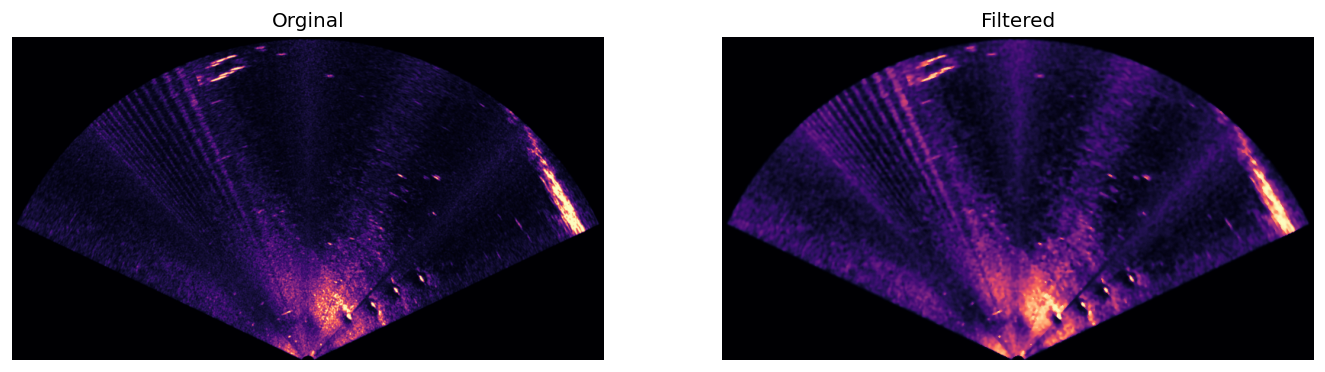

In [ ]:
# # get sample
# idx = 200
# t, frame, pose_gt, depth = data_generator.get_sample(idx, return_visu=False, return_depth=True)
# frame = frame.squeeze(0)
# print(frame.shape)

# # filter 
# frame_filtered = fls_filter(frame)

# # convert do display format 
# frame_org_np = display_format(frame)
# frame_filtered_np = display_format(frame_filtered)

# fig, ax = plt.subplots(1, 2, figsize=(14, 7), dpi=120)

# ax[0].imshow(frame_org_np, cmap = 'magma')
# ax[0].set_title(f'Orginal')

# ax[1].imshow(frame_filtered_np, cmap = 'magma')
# ax[1].set_title(f'Filtered')



# ax[0].axis('off')
# ax[1].axis('off')
# plt.show()


In [ ]:
# def visualize_loftr_matches(visu, num_matches=100):

#     img = visu['combined_imgs']
#     pts1 = visu['pts1']
#     pts2 = visu['pts2']
#     offset_x = visu['pts2_offset'][1]

#     if len(pts1) == 0:
#         print("Brak dopasowań do wyświetlenia!")
#         return

#     n = min(len(pts1), num_matches)
#     indices = np.random.choice(len(pts1), n, replace=False)

#     fig, ax = plt.subplots(figsize=(14, 7), dpi=120)
#     ax.imshow(img)

#     for i in indices:
#         x1, y1 = pts1[i]
#         x2, y2 = pts2[i]

#         ax.plot([x1, x2 + offset_x], [y1, y2], color='cyan', linewidth=0.8, alpha=0.5)
#         ax.plot(x1, y1, 'ro', markersize=3)
#         ax.plot(x2 + offset_x, y2, 'go', markersize=3)

#     ax.set_title(f'Matched points ({n}/{len(pts1)} points displayed)')
#     ax.axis('off')
#     plt.show()

(424, 776)
torch.Size([1, 424, 776])


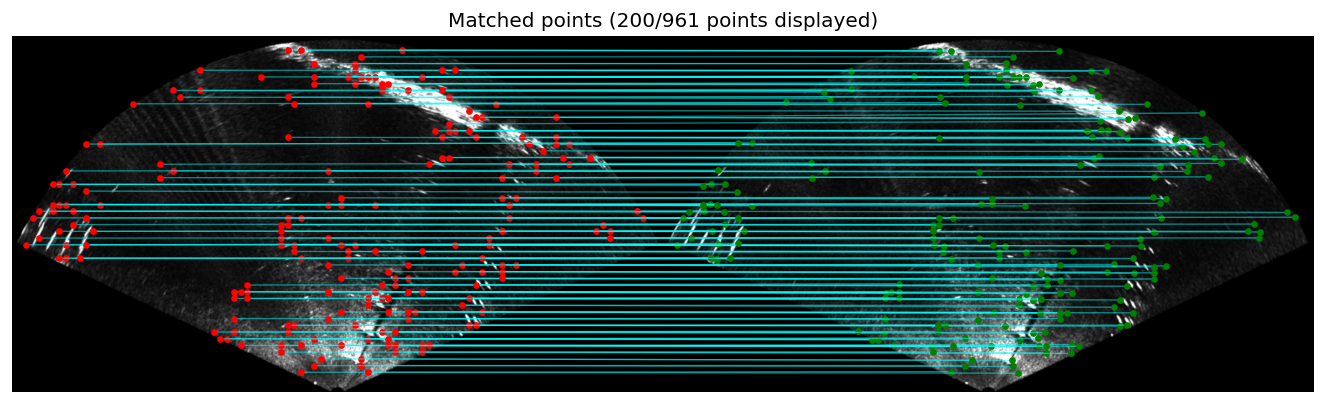

KeyError: 'inlier_num'

In [ ]:
# from src.models.odometry2d import sonar_odometry

# model = sonar_odometry(model_config, sonar_config, device = device,
#                        depth_compesation = True,
#                        key_frames = True,
#                        input_img_format = 'cart')

# idx1 = 400
# idx2 = 404

# t1, frame1, pose_g1, depth1 = data_generator.get_sample(idx1, return_visu=False, return_depth=True)
# t2, frame2, pose_g2, depth2 = data_generator.get_sample(idx2, return_visu=False, return_depth=True)

# mask_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/data/aracati2017/mask_424x776.png'
# mask_np = cv2.imread(mask_pth, 0)
# print(mask_np.shape)
# mask_torch = torch.tensor(mask_np, dtype=torch.float, device=device)
# mask_torch = mask_torch.squeeze(-1).unsqueeze(0)
# print(mask_torch.shape)

# model.set_init_state(0.0, 0.0, 0.0, frame1.squeeze(1), mask_torch)


# pred_pose, pred_azimuth, visu = model(frame2.squeeze(1).to(device), depth2.to(device), return_visu = True)

# visualize_loftr_matches(visu, num_matches=200)

# print(f"Inliers: {visu['inlier_num']}/{visu['pts1'].shape[0]}")

In [25]:

# --- 5. EWALUACJA I PORÓWNANIE ---
print("--- URUCHAMIANIE DOPASOWANIA: BEZ FILTRACJI ---")
metrics_org = evaluate_loftr_pair(frame1, frame2, mask_torch, matcher)

print("\n--- URUCHAMIANIE DOPASOWANIA: PO FILTRACJI CLAHE + Median ---")
metrics_filt = evaluate_loftr_pair(frame1_filtered, frame2_filtered, mask_torch, matcher)

# Wypisanie sformatowanych metryk do konsoli
print("\n" + "="*50)
print(f"{'METRYKA':<25} | {'BEZ FILTRA':<10} | {'Z FILTREM':<10}")
print("-" * 50)
print(f"{'Wszystkie dopasowania':<25} | {metrics_org['total_matches']:<10} | {metrics_filt['total_matches']:<10}")
print(f"{'Poprawne (Inliers RANSAC)':<25} | {metrics_org['inliers_abs']:<10} | {metrics_filt['inliers_abs']:<10}")
print(f"{'Skuteczność (Inliers %)':<25} | {metrics_org['inliers_ratio']:.1%}{'':<5} | {metrics_filt['inliers_ratio']:.1%}")
print(f"{'Średnia pewność (Conf)':<25} | {metrics_org['mean_conf']:.3f}{'':<5} | {metrics_filt['mean_conf']:.3f}")
print("=" * 50)

# Generowanie obrazów
plot_loftr_evaluation(frame1, frame2, metrics_org, "PRZED FILTRACJĄ")
plot_loftr_evaluation(frame1_filtered, frame2_filtered, metrics_filt, "PO FILTRACJI (CLAHE + MedianBlur)")

--- URUCHAMIANIE DOPASOWANIA: BEZ FILTRACJI ---

--- URUCHAMIANIE DOPASOWANIA: PO FILTRACJI CLAHE + Median ---

METRYKA                   | BEZ FILTRA | Z FILTREM 
--------------------------------------------------
Wszystkie dopasowania     | 1365       | 1193      
Poprawne (Inliers RANSAC) | 1234       | 1088      
Skuteczność (Inliers %)   | 90.4%      | 91.2%
Średnia pewność (Conf)    | 0.769      | 0.757


error: OpenCV(4.13.0) :-1: error: (-5:Bad argument) in function 'drawMatches'
> Overload resolution failed:
>  - Can't parse 'matchesMask'. Sequence item with index 0 has a wrong type
>  - drawMatches() missing required argument 'matchesThickness' (pos 7)
>  - Can't parse 'matchesMask'. Sequence item with index 0 has a wrong type
>  - drawMatches() missing required argument 'matchesThickness' (pos 7)


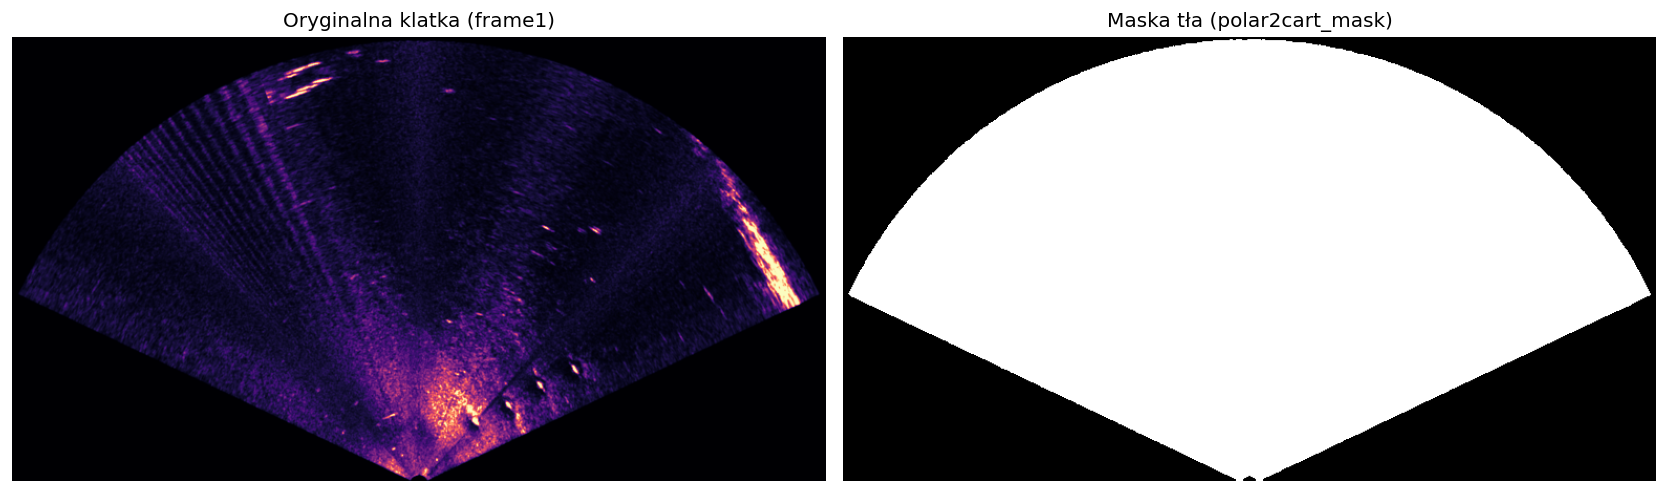

True

In [ ]:
# mask_real = ((mask_np == 0)*255).astype(np.uint8)
# # 3. Wyświetlanie obok siebie
# fig, ax = plt.subplots(1, 2, figsize=(14, 7), dpi=120)

# # Oryginał
# ax[0].imshow(img_org, cmap="magma")
# ax[0].set_title("Oryginalna klatka (frame1)")
# ax[0].axis("off")

# # Maska
# # Używamy cmap='gray', gdzie True (tło) będzie białe, a False (sonar) czarne
# # Możesz też użyć cmap='jet' lub innego, jeśli wolisz żywsze kolory
# ax[1].imshow(mask_real, cmap="gray")
# ax[1].set_title("Maska tła (polar2cart_mask)")
# ax[1].axis("off")

# plt.tight_layout()
# plt.show()

# cv2.imwrite('C:/Users/janis/Projekty/Magisterka/SonarOdometry/data/aracati2017/mask_424x776.png', mask_real)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.77582..10.394652].


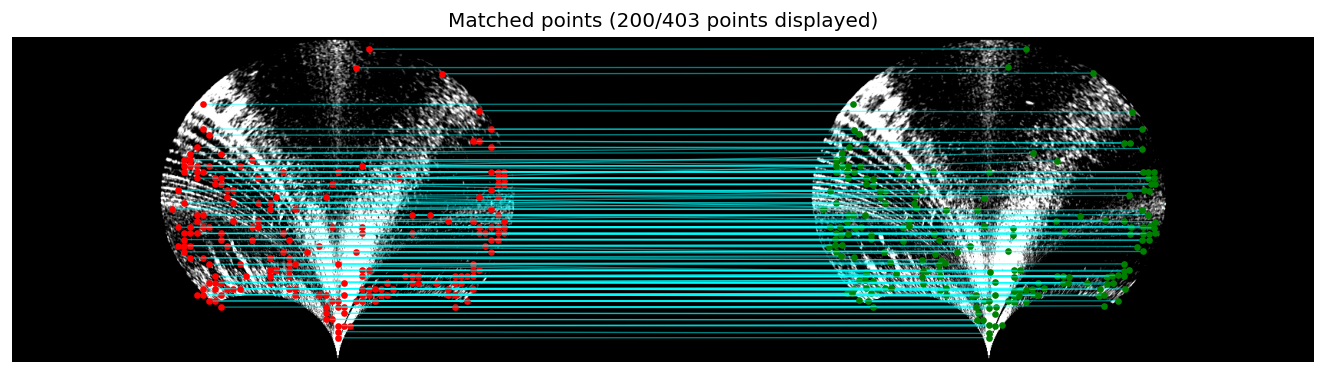

Inliers: 0.48635235732009924/403


In [ ]:
model = sonar_odometry(model_config, sonar_config, device = device,
                       depth_compesation = True,
                       key_frames = True)

idx1 = 0
idx2 = 1

t1, frame1, pose_g1, depth1 = data_generator.get_sample(idx1, return_visu=False, return_depth=True)
t2, frame2, pose_g2, depth2 = data_generator.get_sample(idx2, return_visu=False, return_depth=True)

frame1_filtered = normalize_sonar_frame(frame1)
model.set_init_state(0.0, 0.0, 0.0, frame1_filtered.squeeze(1))

frame2_filtered = normalize_sonar_frame(frame2)
pred_pose, pred_azimuth, visu = model(frame2_filtered.squeeze(1).to(device), depth.to(device), return_visu = True)

visualize_loftr_matches(visu, num_matches=200)

print(f"Inliers: {visu['inlier_num']}/{visu['pts1'].shape[0]}")

Wnioski: 

- Filtracja (median, median + CLAHE) zmniejszały liczbę inlierów (procent)
- Normalizacja zostawiałą powodbny provent inlierów ale liczba wykrywtych punktów spadała kilkukrotnie.

Create mask

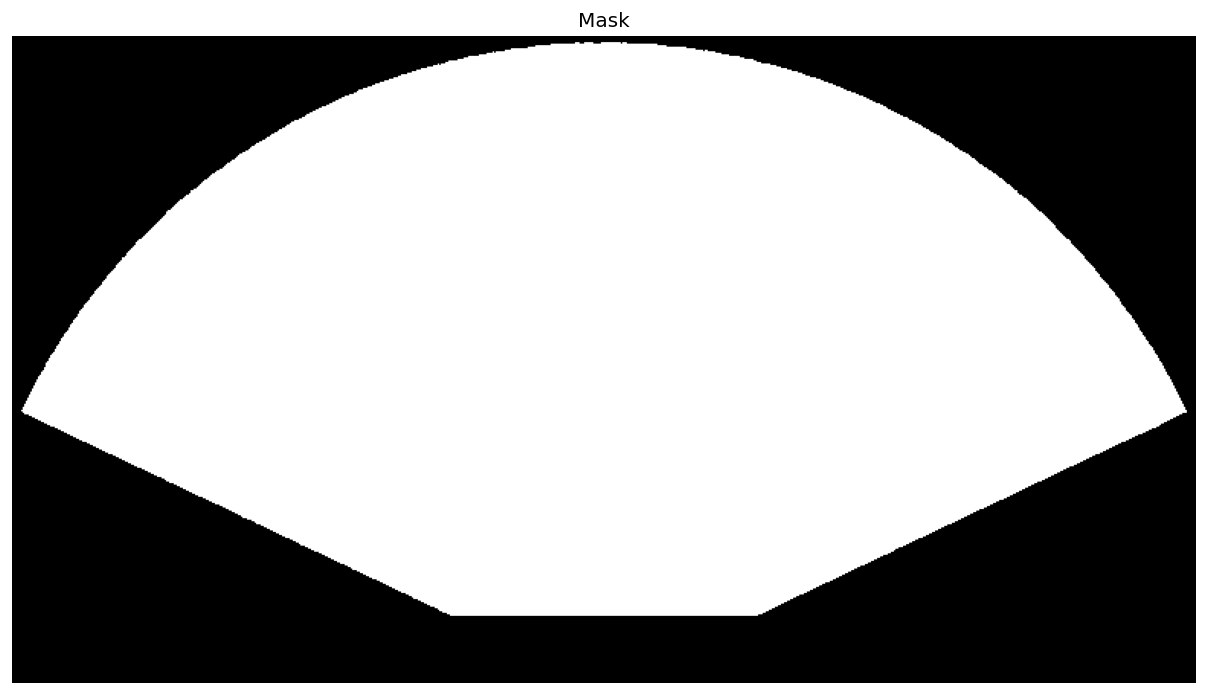

(424, 776)
torch.Size([1, 424, 776])


In [ ]:
# ## modify mask 

# mask_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/data/aracati2017/mask_424x776.png'
# mask_np = cv2.imread(mask_pth, 0)

# h, w = mask_np.shape

# # add dead zone
# mask_modified = mask_np
# mask_modified[int(h*0.9):h, :] = 0

# # add erosion on edges
# kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))  
# eroded_mask = cv2.erode(mask_np, kernel, iterations=1)

# cv2.imwrite('C:/Users/janis/Projekty/Magisterka/SonarOdometry/data/aracati2017/mask_deadzone_424x776.png', eroded_mask)
# fig, ax = plt.subplots(figsize=(14, 7), dpi=120)
# ax.imshow(eroded_mask, cmap = 'gray')

# ax.set_title(f'Mask')
# ax.axis('off')
# plt.show()


# print(mask_np.shape)
# mask_torch = torch.tensor(mask_np, dtype=torch.float, device=device)
# mask_torch = mask_torch.squeeze(-1).unsqueeze(0)
# print(mask_torch.shape)
